In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
from torch.nn.utils.parametrizations import spectral_norm as SN

cuda


In [26]:
transform = transforms.Compose([transforms.Resize((64, 64)),
                               transforms.ToTensor(),
                               transforms.Normalize([0.5, 0.5, 0.5],
                                                    [0.5, 0.5, 0.5])])
dataset = ImageFolder(root = r'C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\animation_gan\image',
                      transform = transform)

batch_size = 128
train_iter = DataLoader(dataset = dataset, batch_size = batch_size, shuffle = True, num_workers = 8, pin_memory = True)

In [27]:
def Generator(inchan = 100, outchan = 3):
    return nn.Sequential(SN(nn.ConvTranspose2d(inchan, 512, 4, 1, 0)),
                         nn.BatchNorm2d(512),
                         nn.ReLU(),

                         SN(nn.ConvTranspose2d(512, 256, 4, 2, 1)),
                         nn.BatchNorm2d(256),
                         nn.ReLU(),

                         SN(nn.ConvTranspose2d(256, 128, 4, 2, 1)),
                         nn.BatchNorm2d(128),
                         nn.ReLU(),

                         SN(nn.ConvTranspose2d(128, 64, 4, 2, 1)),
                         nn.BatchNorm2d(64),
                         nn.ReLU(),

                         SN(nn.ConvTranspose2d(64, outchan, 4, 2, 1)),
                         nn.Tanh()).to(device)

In [28]:
def Discriminator():
    return nn.Sequential(SN(nn.Conv2d(3, 64, 4, 2, 1)),
                         nn.ReLU(),

                         SN(nn.Conv2d(64, 128, 4, 2, 1)),
                         nn.ReLU(),

                         SN(nn.Conv2d(128, 256, 4, 2, 1)),
                         nn.ReLU(),

                         SN(nn.Conv2d(256, 512, 4, 2, 1)),
                         nn.ReLU(),

                         SN(nn.Conv2d(512, 1, 4, 1, 0)),
                         nn.Sigmoid(),
                         nn.Flatten()).to(device)

In [29]:
def test_epoch():
    G.eval()
    noise = torch.randn(4, 100, 1, 1).to(device)
    fake_samples = G(noise).cpu().detach()
    for i in range(4):
        ax = plt.subplot(1, 4, i+1)
        img = (fake_samples.cpu().detach()[i]/2+0.5).permute(1, 2, 0)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
    plt.subplots_adjust(hspace = -0.6)
    plt.show()

In [30]:
def visual_output(G_loss, D_loss):
    G_loss_np = np.array(G_loss)
    D_loss_np = np.array(D_loss)
    fig, ax = plt.subplots(figsize = (8, 8))
    ax.plot(G_loss_np[:, 0], G_loss_np[:, 1], c = 'g', label = 'G_loss')
    ax.plot(D_loss_np[:, 0], D_loss_np[:, 1], c = 'r', label = 'D_loss')
    ax.set_title('G_loss & D_loss in Each Epoch')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

    plt.show()

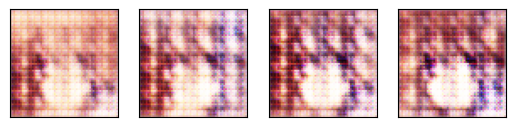

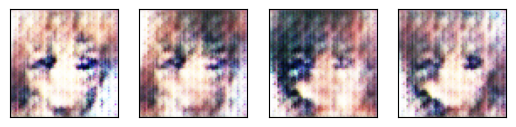

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001C8FC300160>
Traceback (most recent call last):
  File "D:\anaconda3\envs\d2l\lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "D:\anaconda3\envs\d2l\lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


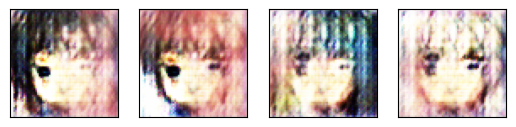

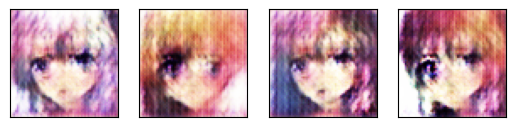

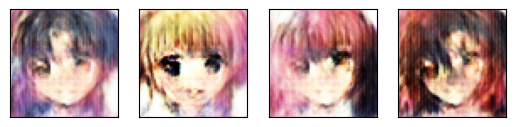

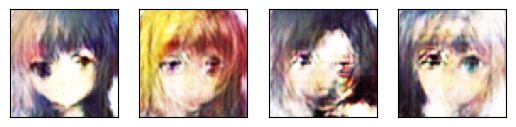

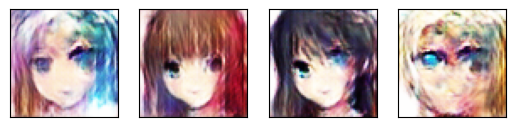

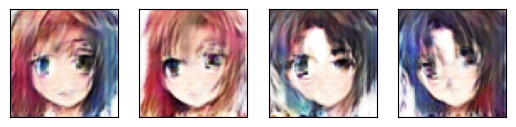

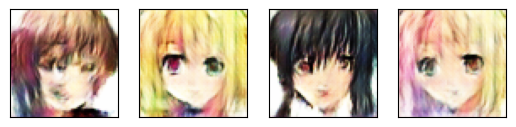

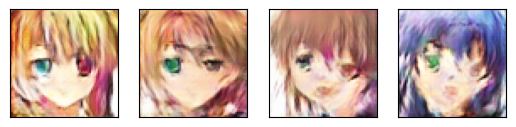

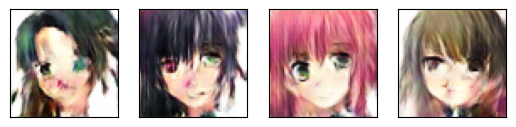

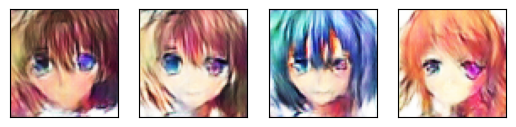

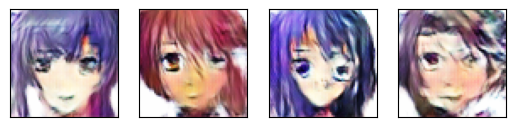

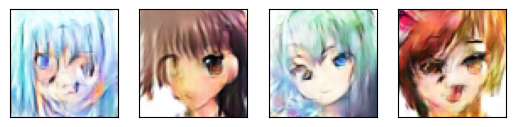

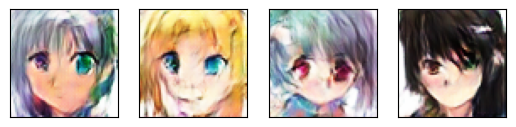

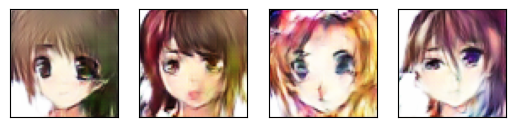

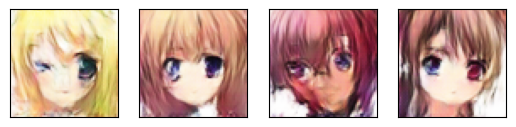

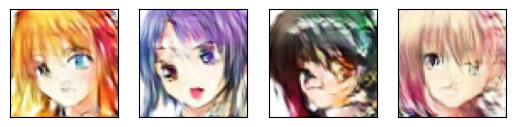

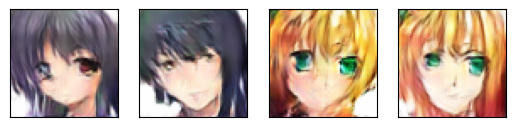

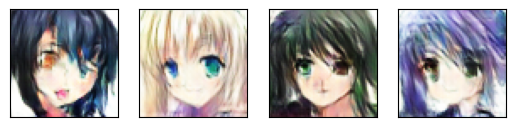

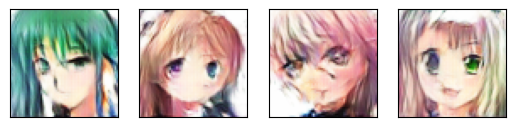

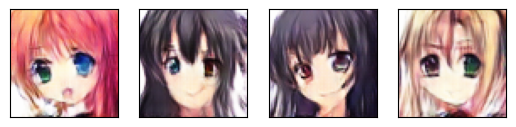

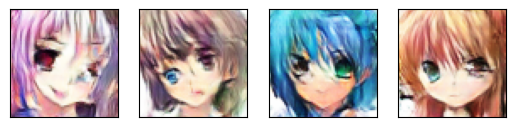

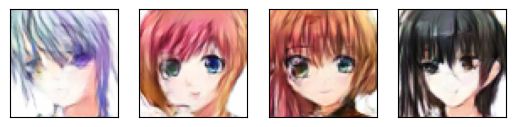

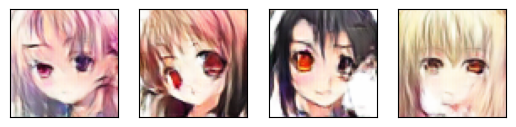

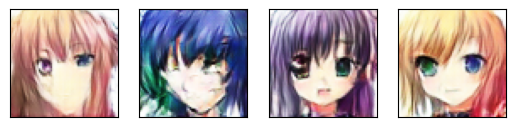

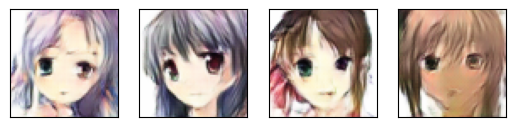

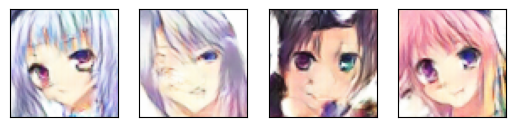

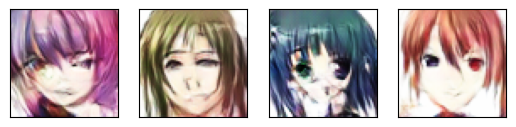

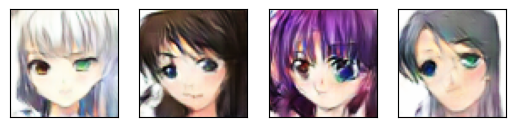

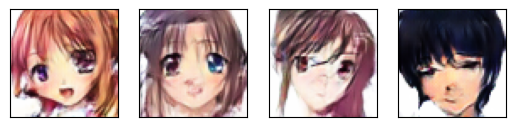

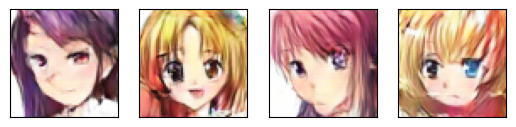

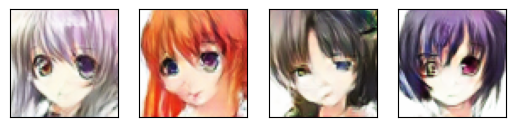

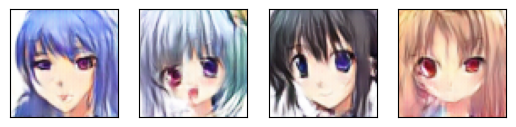

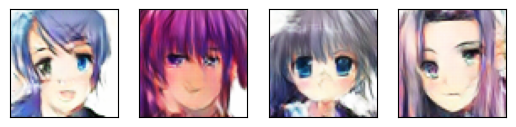

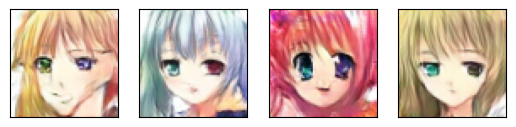

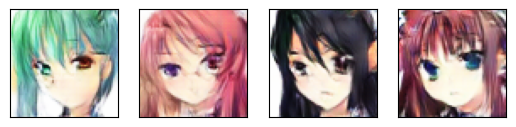

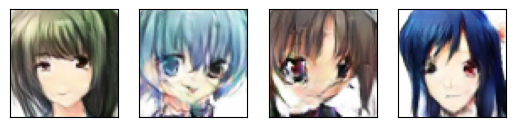

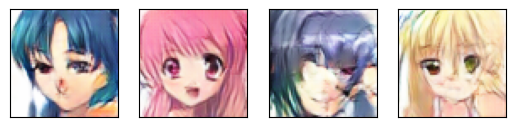

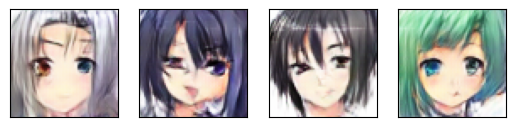

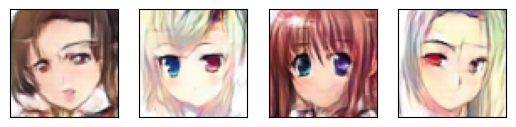

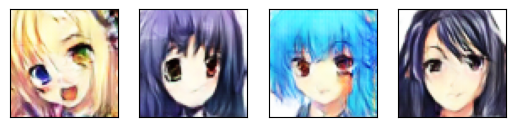

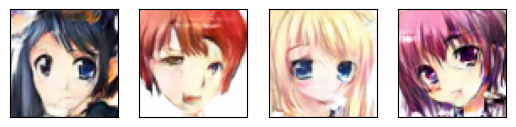

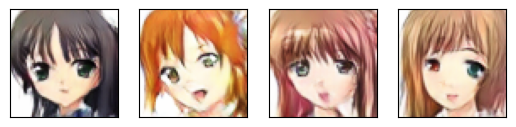

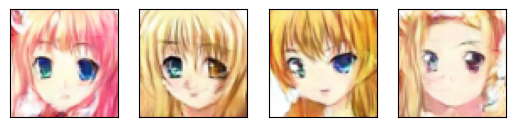

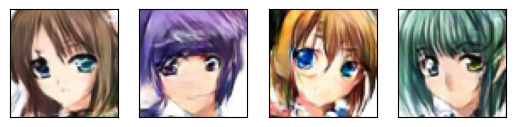

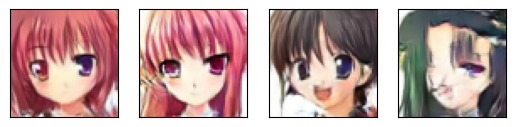

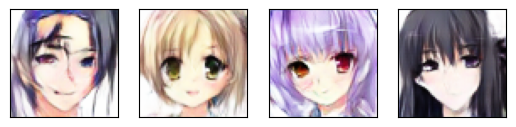

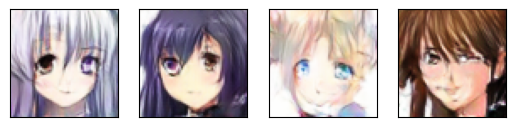

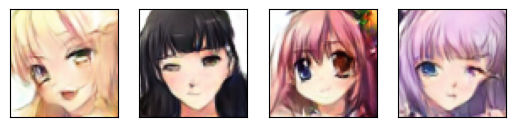

Last epoch (51) G_loss = 0.9060221382789688
Last epoch (51) D_loss = 0.6208075523616322


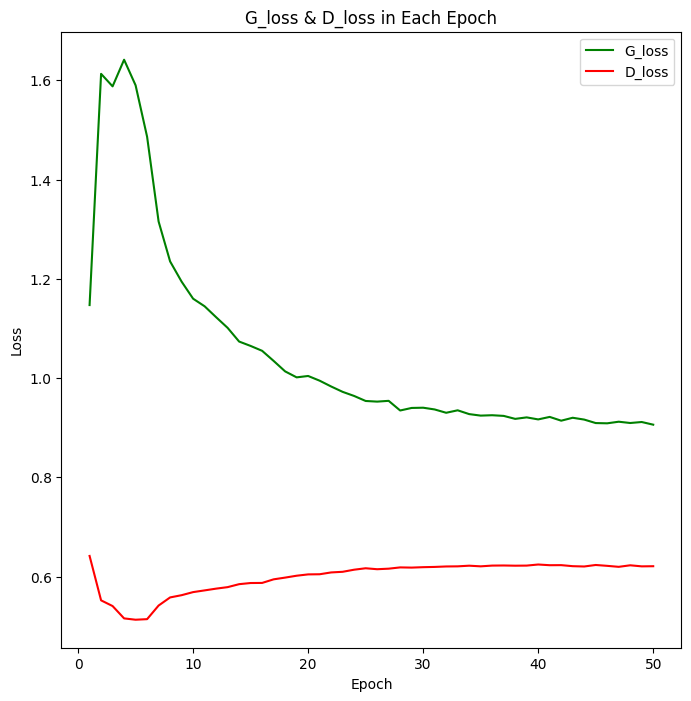

NotSupportedError: Comprehension ifs are not supported yet:
  File "D:\anaconda3\envs\d2l\lib\site-packages\torch\nn\utils\parametrizations.py", line 451
            # permute dim to front
            weight = weight.permute(
                self.dim, *(d for d in range(weight.dim()) if d != self.dim)
            )
    


In [31]:
if __name__ == "__main__":
    D = Discriminator()
    G = Generator()
    opt_G = torch.optim.Adam(G.parameters(), lr = 0.002, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr = 0.002, betas=(0.5, 0.999))
    loss = nn.BCELoss()
    G_loss_hist = []
    D_loss_hist = []
    num_epochs = 50
    for epoch in range(num_epochs):
        #D
        roundary_D_loss = 0.0
        roundary_G_loss = 0.0
        for X, _ in train_iter:
            G.train()
            X = X.to(device)
            batchsize = X.size(0)
            noise = torch.randn(batchsize, 100, 1, 1).to(device)
            fake_loss = loss(D(G(noise).detach()), torch.zeros(batchsize, 1).to(device))
            true_loss = loss(D(X), torch.full((batchsize, 1), 0.95).to(device))
            avg_loss = (fake_loss + true_loss) / 2
            opt_D.zero_grad()
            avg_loss.backward()
            opt_D.step()
            roundary_D_loss += avg_loss.item()

            #G
            G.train()
            noise = torch.randn(batchsize, 100, 1, 1).to(device)
            G_loss = loss(D(G(noise)), torch.full((batchsize, 1), 0.95).to(device))
            opt_G.zero_grad()
            G_loss.backward()
            opt_G.step()
            roundary_G_loss += G_loss.item()

        G_loss_hist.append((epoch + 1, roundary_G_loss / len(train_iter)))
        D_loss_hist.append((epoch + 1, roundary_D_loss / len(train_iter)))
        test_epoch()

    print(f"Last epoch ({num_epochs + 1}) G_loss = {G_loss_hist[-1][1]}")
    print(f"Last epoch ({num_epochs + 1}) D_loss = {D_loss_hist[-1][1]}")
    visual_output(G_loss_hist, D_loss_hist)

    

In [34]:
G.eval()
example = torch.randn(1, 100, 1, 1, device=device)

with torch.no_grad():
    scripted = torch.jit.trace(G, example)

torch.jit.save(scripted, r'C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\animation_gan\model\anime_gan.pt')